<a href="https://colab.research.google.com/github/HowardHNguyen/Data_Science_for_Marketing_Solutions/blob/main/NVDA_Stock_Analysis_with_Prophet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install prophet

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.ensemble import StackingClassifier
import nltk
from transformers import pipeline
from datetime import datetime

In [3]:
# Define the data range
start_date = datetime(2020, 1, 1)
end_date = datetime.now()

In [4]:
#!pip install yfinance
#import yfinance as yf

data = yf.download('NVDA', start=start_date, end=end_date)

/tmp/ipykernel_10041/3038887400.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('NVDA', start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


In [5]:
data

Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2020-01-02,5.957139,5.957139,5.877929,5.928335,237536000
2020-01-03,5.861789,5.905491,5.812872,5.837703,205384000
2020-01-06,5.886371,5.891585,5.742601,5.768673,262636000
2020-01-07,5.957636,6.003324,5.869735,5.914679,314856000
2020-01-08,5.968809,6.010028,5.913437,5.953414,277108000
...,...,...,...,...,...
2026-09-28,228.860001,233.210007,228.039993,229.750000,142344300
2026-09-29,227.210007,232.820007,227.029999,230.970001,101494900


In [6]:
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
import pandas as pd
# First, reset the index if 'Date' is not already a column
df_reset = data.reset_index()

In [8]:
# Select the 'Date' and 'Close' columns
df_selected = df_reset[['Date', 'Close']]

In [9]:
# Rename the columns to 'ds' and 'y'
df_renamed = df_selected.rename(columns={'Date': 'ds', 'Close': 'y'})

In [10]:
# Now 'df_renamed' contains only the 'ds' and 'y' columns
print(df_renamed.head())

Price          ds         y
Ticker                 NVDA
0      2020-01-02  5.957139
1      2020-01-03  5.861789
2      2020-01-06  5.886371
3      2020-01-07  5.957636
4      2020-01-08  5.968809


In [11]:
df_renamed.columns = ['ds', 'y']

In [12]:
df_renamed.head()

,ds,y
0,2020-01-02,5.957139
1,2020-01-03,5.861789
2,2020-01-06,5.886371
3,2020-01-07,5.957636
4,2020-01-08,5.968809


In [13]:
df_renamed.tail()

,ds,y
1692,2026-09-28,228.860001
1693,2026-09-29,227.210007
1694,2026-09-30,228.380005
1695,2026-10-01,230.860001
1696,2026-10-02,NaN


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


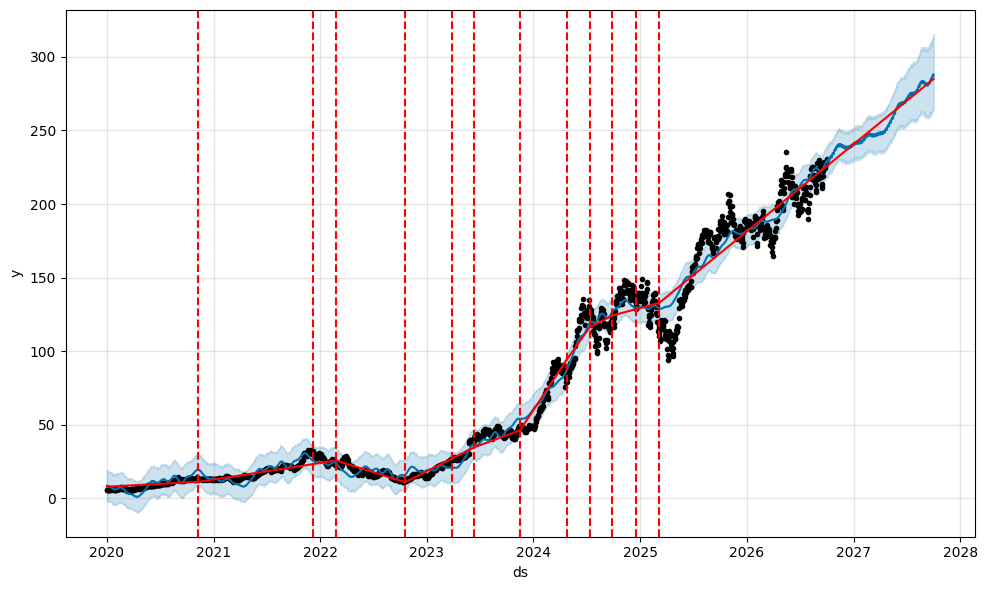

In [14]:
from prophet import Prophet
import pandas as pd
from matplotlib import pyplot as plt

# Assuming df_renamed is your DataFrame with 'ds' and 'y' columns
m = Prophet()
m.fit(df_renamed)
future = m.make_future_dataframe(periods=365)
forecast = m.predict(future)
fig = m.plot(forecast)
a = add_changepoints_to_plot(fig.gca(), m, forecast)
plt.show()

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


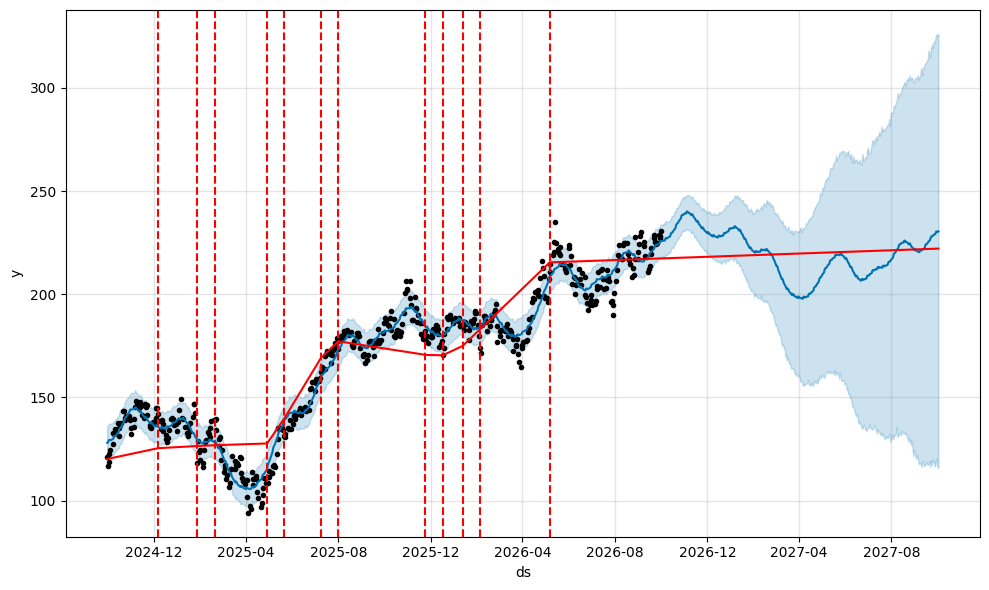

In [15]:
m = Prophet()
m.fit(df_renamed.iloc[-252*2:])
future = m.make_future_dataframe(periods=365)
forecast = m.predict(future)
fig = m.plot(forecast);
a = add_changepoints_to_plot(fig.gca(), m, forecast)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


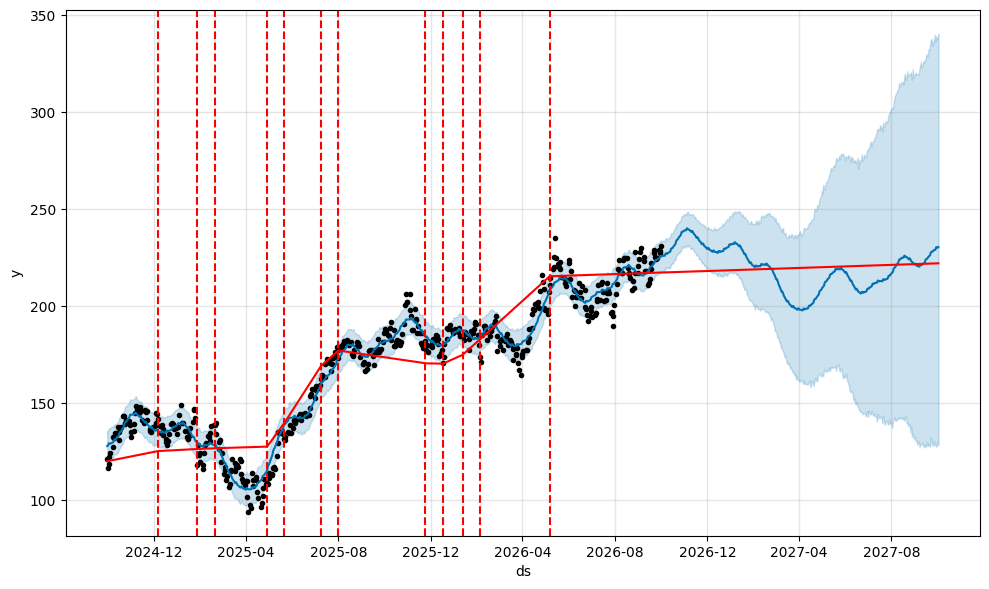

In [16]:
m = Prophet()
m.fit(df_renamed.iloc[-252*2:])
future = m.make_future_dataframe(periods=365)
forecast = m.predict(future)
fig = m.plot(forecast);
a = add_changepoints_to_plot(fig.gca(), m, forecast)

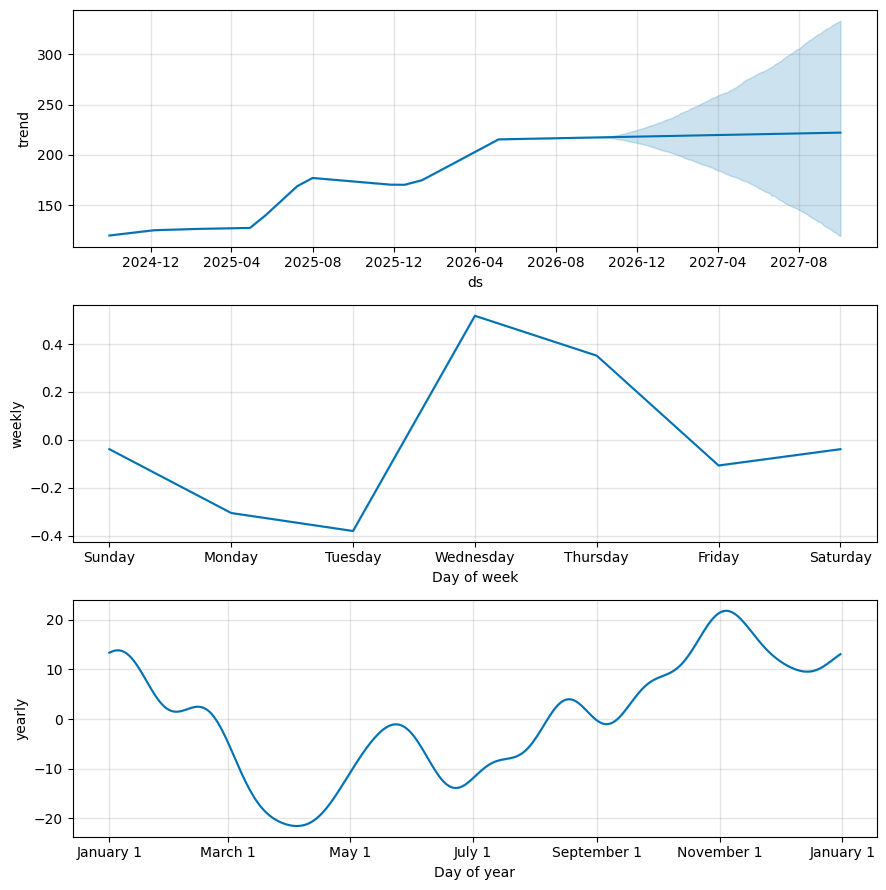

In [17]:
m.plot_components(forecast);

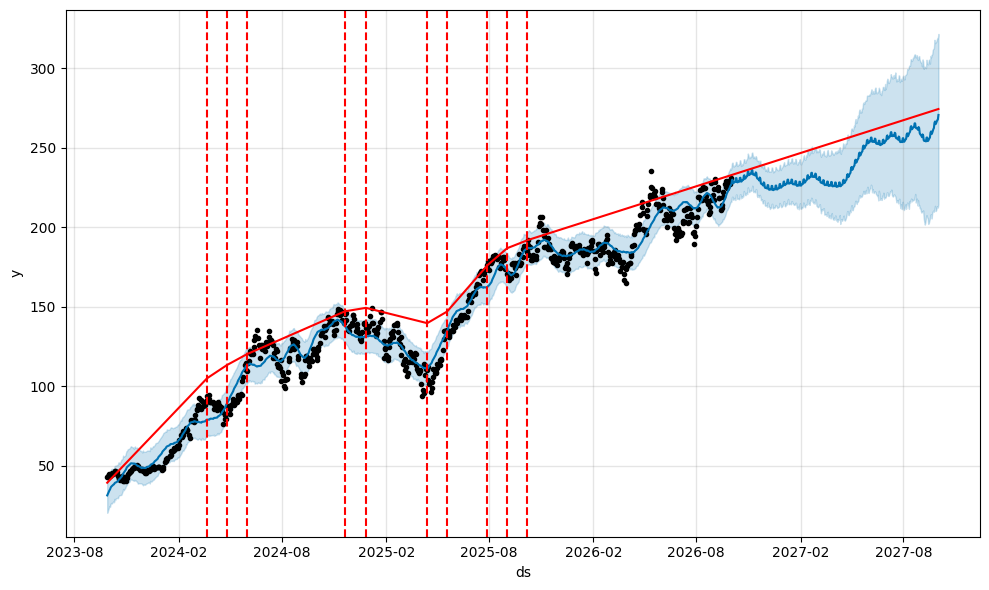

In [18]:
# BAD!!! From blog articles
m = Prophet(daily_seasonality=True)
m.fit(df_renamed.iloc[-252*3:])
future = m.make_future_dataframe(periods=365)
forecast = m.predict(future)
fig = m.plot(forecast);
a = add_changepoints_to_plot(fig.gca(), m, forecast)

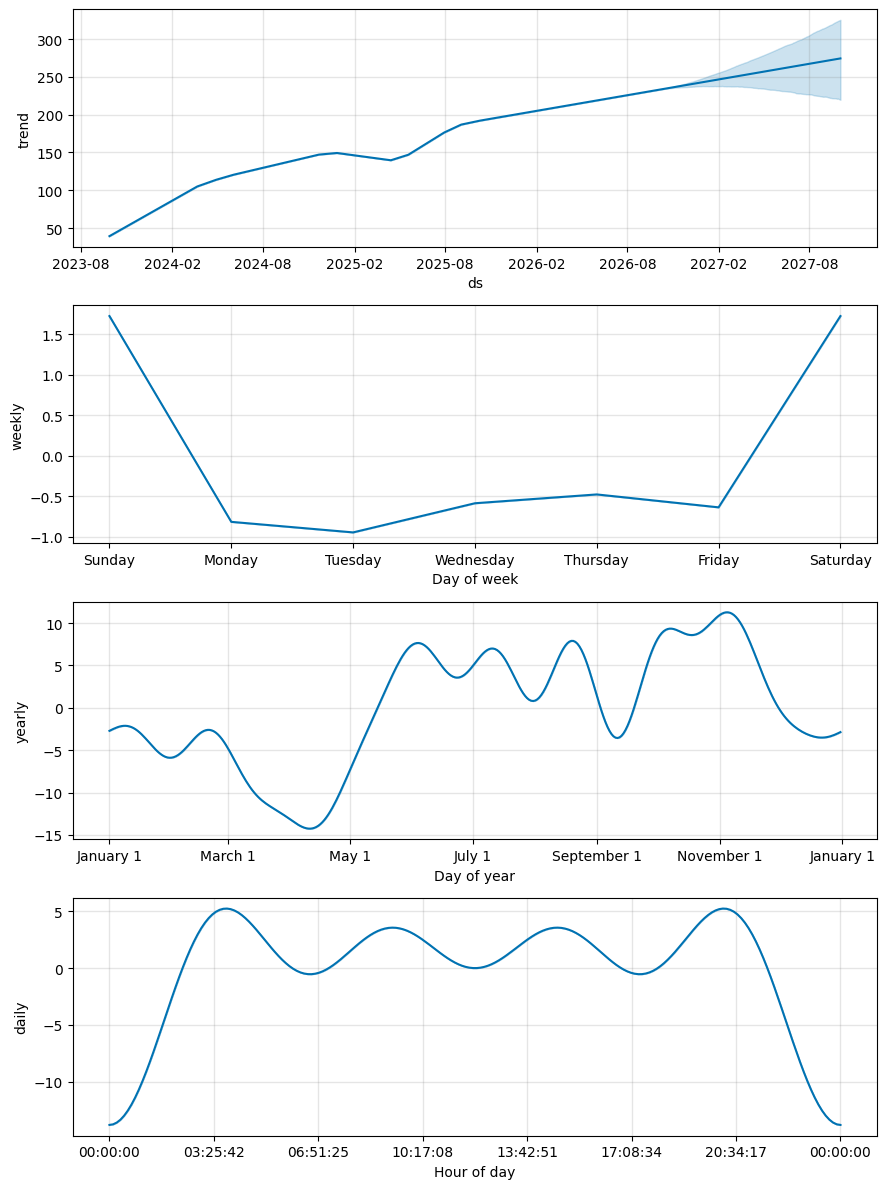

In [19]:
m.plot_components(forecast);

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


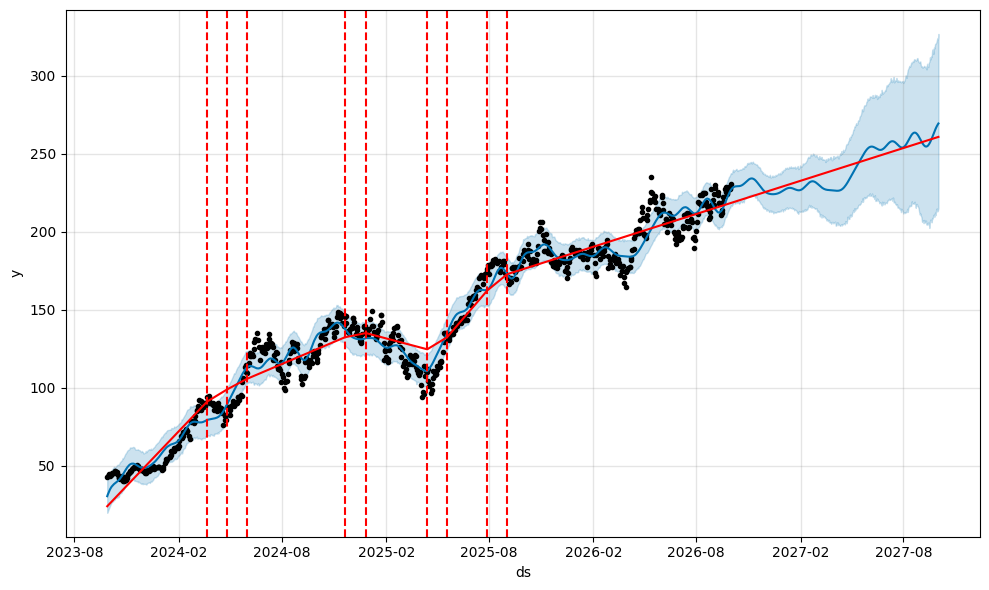

In [20]:
m = Prophet(weekly_seasonality=False)
m.fit(df_renamed.iloc[-252*3:])
future = m.make_future_dataframe(periods=365)
forecast = m.predict(future)
fig = m.plot(forecast);
a = add_changepoints_to_plot(fig.gca(), m, forecast)

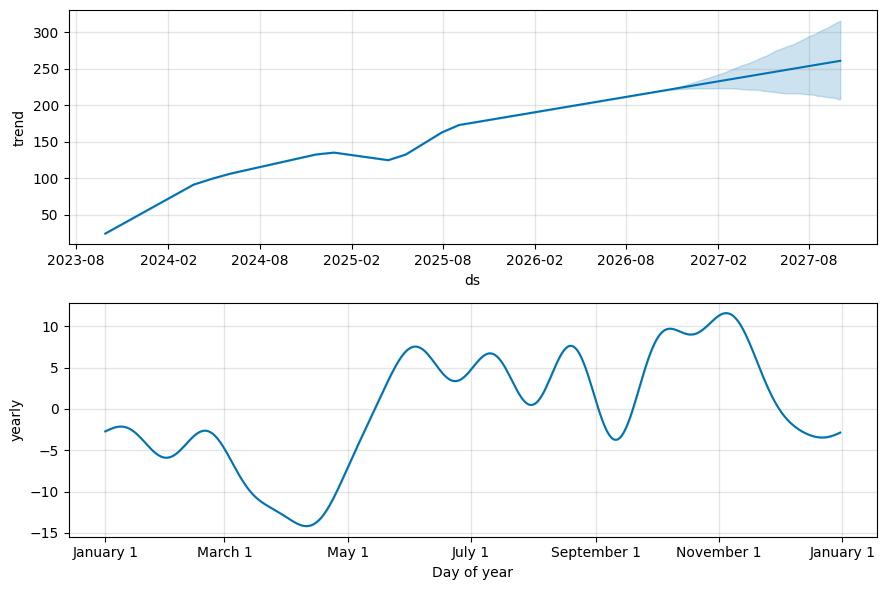

In [21]:
m.plot_components(forecast);

### Cross-Validation

In [22]:
from prophet.diagnostics import cross_validation
from prophet.diagnostics import performance_metrics
from prophet.plot import plot_cross_validation_metric

In [23]:
m = Prophet(weekly_seasonality=False)

In [24]:
m.fit(df_renamed[-252*2:])

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [25]:
# try period=15, horizon=30
# try period=30, horizon=60
df_cv = cross_validation(
    m,
    initial='365 days',
    period='5 days',
    horizon='5 days')

INFO:prophet:Making 73 forecasts with cutoffs between 2025-10-01 00:00:00 and 2026-09-26 00:00:00


  0%|          | 0/73 [00:00<?, ?it/s]

ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted


In [26]:
df_cv.head(20)

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2025-10-02,186.559594,180.831714,192.333625,188.438553,2025-10-01
1,2025-10-03,187.540000,181.628330,193.033374,187.171570,2025-10-01
2,2025-10-06,190.503169,184.786815,196.234321,185.096527,2025-10-01
3,2025-10-07,190.808320,185.366651,196.679102,184.597733,2025-10-06
4,2025-10-08,191.757291,185.875158,197.481560,188.658005,2025-10-06
5,2025-10-09,192.701080,187.004484,198.514988,192.109756,2025-10-06
6,2025-10-10,193.636246,188.086178,199.313871,182.722244,2025-10-06
7,2025-10-13,193.174660,187.598811,198.549828,187.869904,2025-10-11
8,2025-10-14,193.990914,188.202199,199.811192,179.599716,2025-10-11
9,2025-10-15,194.795246,188.832125,200.571040,179.400192,2025-10-11


In [27]:
df_cv.shape

(251, 6)

In [28]:
naive = df_cv[['ds', 'yhat', 'y', 'cutoff']].copy()

In [29]:
import pandas as pd
import numpy as np

# Assuming naive and df_renamed are your DataFrames, and 'cutoff' is a datetime column
# Ensure 'cutoff' in naive and the index of df_renamed are datetime
naive['cutoff'] = pd.to_datetime(naive['cutoff'])
df_renamed.index = pd.to_datetime(df_renamed.index)

# Sort both DataFrames by date to ensure merge_asof works correctly
naive = naive.sort_values('cutoff').reset_index(drop=True)
df_temp = df_renamed.reset_index().rename(columns={'index': 'cutoff'})

# Use merge_asof to find the nearest previous cutoff date in df_renamed
merged = pd.merge_asof(
    naive[['cutoff']],
    df_temp[['cutoff', 'y']],
    on='cutoff',
    direction='backward'  # Look for the nearest previous cutoff
)

# Assign the 'y' values to naive['yhat']
naive['yhat'] = merged['y'].values

In [ ]:
naive_storage = np.zeros(naive.shape[0])
one_day = pd.Timedelta(0, 'day')
for i, row in naive.iterrows():
  cutoff = row['cutoff']
  # print(cutoff)

  # must find last cutoff that actually exists in df
  while cutoff not in df_renamed.index:
    cutoff = cutoff - one_day

  naive_storage[i] = df_renamed.loc[cutoff]['y']

naive['yhat'] = naive_storage

In [ ]:
pm = performance_metrics(df_cv)
pm['smape'].mean()

In [ ]:
naive_metrics = performance_metrics(naive)
naive_metrics['smape'].mean()

In [ ]:
plot_cross_validation_metric(df_cv, metric='smape');

### Cross-Validation with Logged Data

In [ ]:
log_goog = df_renamed.copy()
log_goog['y'] = np.log(df_renamed['y'])

In [ ]:
m = Prophet(weekly_seasonality=False)
m.fit(log_goog[-252*2:])
df_cv = cross_validation(
    m,
    initial='365 days',
    period='30 days',
    horizon='60 days')
pm = performance_metrics(df_cv)
pm['smape'].mean()

In [ ]:
naive = df_cv[['ds', 'yhat', 'y', 'cutoff']].copy()
naive_storage = np.zeros(naive.shape[0])
for i, row in naive.iterrows():
  cutoff = row['cutoff']
  # print(cutoff)

  # must find last cutoff that actually exists in df
  while cutoff not in log_goog.index:
    cutoff = cutoff - pd.Timedelta(1, 'day')

  naive_storage[i] = log_goog.loc[cutoff]['y']

naive['yhat'] = naive_storage
naive_metrics = performance_metrics(naive)
naive_metrics['smape'].mean()

In [ ]:
plot_cross_validation_metric(df_cv, metric='smape');

![](https://deeplearningcourses.com/notebooks_v3_pxl?sc=Hr2pZhny7mUJkUdizfUyuw&n=Prophet+Stocks)